# Line measurements

While I am using the `EmFit` measurements from the VAC to make an initial selection that is saved in `../data/emp-candidates.fits`, the exercise related to the stacks showed me that there are some inconsistencies compared with the way I measure the lines in the stacks. Because of this, I will re-measure all the lines to make a comparison and then work on the stacks based on my own measurements.

In [1]:
%run ../src/emline-inspect-functions.py

In [2]:
emps = Table.read("../data/emp-candidates.fits", format="fits").to_pandas()
emps = emps.query("HA_N_FLUX / HB_N_FLUX < 10")

In [3]:
vg_flux_cols = ["vg_hb", "vg_oiii5007", "vg_ha", "vg_nii6583"]
vg_err_cols = [f"{col}_err" for col in vg_flux_cols]
for col in vg_flux_cols + vg_err_cols:
    emps[col] = np.nan

for idx, targetid in enumerate(emps["TARGETID"]):
    spec = Table.read(f"../data/spectra/{targetid}.fits", format="fits")
    z = emps["Z"].iloc[idx]

    result = fit_spectrum_lines(spec, z)

    emps.loc[emps.index[idx], "vg_hb"] = result["hb"]["popt"][2]
    emps.loc[emps.index[idx], "vg_hb_err"] = result["hb"]["perr"][2]

    emps.loc[emps.index[idx], "vg_oiii5007"] = result["o3_b"]["popt"][2]
    emps.loc[emps.index[idx], "vg_oiii5007_err"] = result["o3_b"]["perr"][2]

    emps.loc[emps.index[idx], "vg_ha"] = result["ha_n2"]["popt"][3]
    emps.loc[emps.index[idx], "vg_ha_err"] = result["ha_n2"]["perr"][3]

    emps.loc[emps.index[idx], "vg_nii6583"] = result["ha_n2"]["popt"][4]
    emps.loc[emps.index[idx], "vg_nii6583_err"] = result["ha_n2"]["perr"][4]


emps["vg_N2"] = np.log10(emps["vg_nii6583"] / emps["vg_ha"])
emps["vg_R3"] = np.log10(emps["vg_oiii5007"] / emps["vg_hb"])


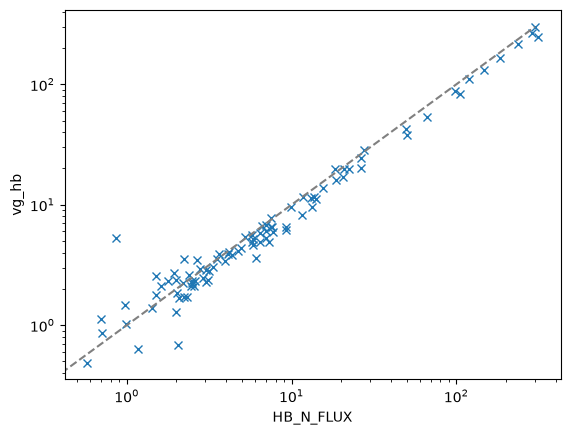

In [4]:
plt.plot(emps["HB_N_FLUX"], emps["vg_hb"], "x")
plt.plot([0, 300], [0, 300], "--", color="gray")
plt.xlabel("HB_N_FLUX")
plt.ylabel("vg_hb")
plt.yscale("log")
plt.xscale("log")

In [5]:
emps.columns

Index(['TARGETID', 'SPECPROD', 'SURVEY', 'PROGRAM', 'HEALPIX', 'TARGET_RA',
       'TARGET_DEC', 'Z', 'HB_N_FLUX', 'HB_N_FLUX_ERR', 'OIII5007_FLUX',
       'OIII5007_FLUX_ERR', 'NII6583_FLUX', 'NII6583_FLUX_ERR', 'HA_N_FLUX',
       'HA_N_FLUX_ERR', 'N2', 'R3', 'ston', 'vg_hb', 'vg_oiii5007', 'vg_ha',
       'vg_nii6583', 'vg_hb_err', 'vg_oiii5007_err', 'vg_ha_err',
       'vg_nii6583_err', 'vg_N2', 'vg_R3'],
      dtype='object')

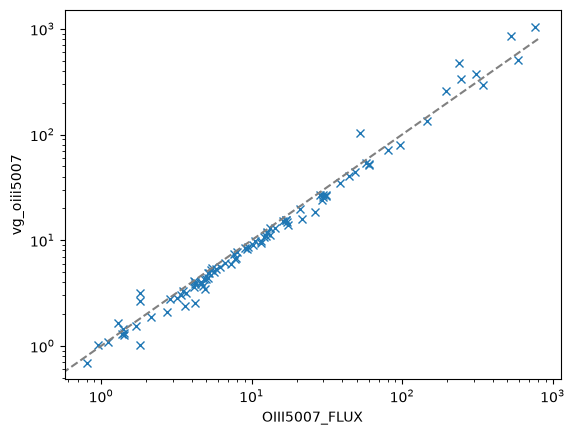

In [6]:
plt.plot(emps["OIII5007_FLUX"], emps["vg_oiii5007"], "x")
plt.plot([0, 800], [0, 800], "--", color="gray")
plt.xlabel("OIII5007_FLUX")
plt.ylabel("vg_oiii5007")
plt.yscale("log")
plt.xscale("log")

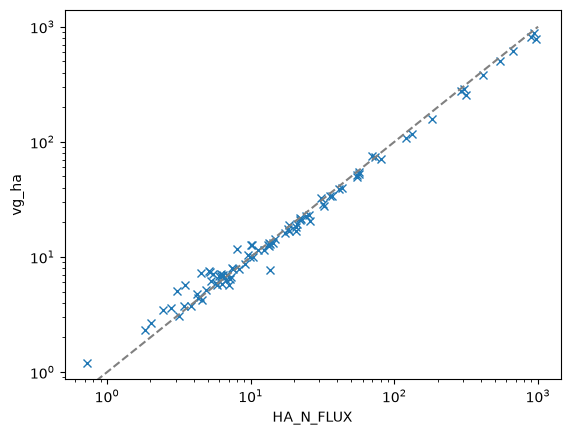

In [7]:
plt.plot(emps["HA_N_FLUX"], emps["vg_ha"], "x")
plt.plot([0, 1000], [0, 1000], "--", color="gray")
plt.xlabel("HA_N_FLUX")
plt.ylabel("vg_ha")
plt.xscale("log")
plt.yscale("log")

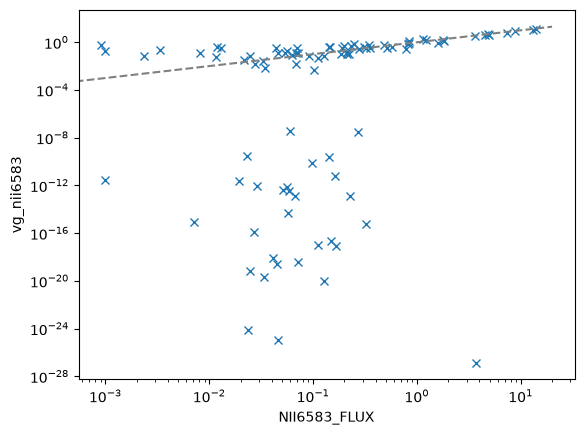

In [8]:
plt.plot(emps["NII6583_FLUX"], emps["vg_nii6583"], "x")
plt.plot([0, 20], [0, 20], "--", color="gray")
plt.xlabel("NII6583_FLUX")
plt.ylabel("vg_nii6583")
plt.xscale("log")
plt.yscale("log")

In [9]:
xedges = np.arange(-2, 0.6, 0.1)
yedges = np.arange(-1, 1.1, 0.1)
x_centers = 0.5 * (xedges[1:] + xedges[:-1])
y_centers = 0.5 * (yedges[1:] + yedges[:-1])

H = np.load("../data/contours.npy")  # This is for reference, comes from SDSS

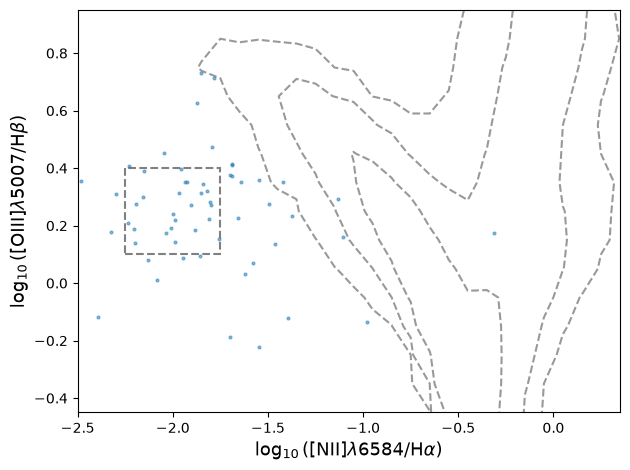

In [10]:
R3_bins = [0.4, 0.25, 0.0]
N2_bins = [-1.8, -2, -2.25]

r3_edges = sorted(R3_bins)
n2_edges = sorted(N2_bins)

plt.figure(3, clear=True)

plt.contour(
    x_centers,
    y_centers,
    H,
    [10, 100, 1000],
    origin="lower",
    linestyles="--",
    colors="0.6",
)

# for i in range(len(r3_edges) - 1):
#     r3_lo, r3_hi = r3_edges[i], r3_edges[i + 1]
#     for j in range(len(n2_edges) - 1):
#         n2_lo, n2_hi = n2_edges[j], n2_edges[j + 1]
#         rect = plt.Rectangle(
#             (n2_lo, r3_lo),
#             n2_hi - n2_lo,
#             r3_hi - r3_lo,
#             linewidth=1.5,
#             edgecolor='k',
#             facecolor='none',
#         )
#         plt.gca().add_patch(rect)

rect = plt.Rectangle(
    (-2.25, 0.1),
    0.5,
    0.3,
    linewidth=1.5,
    edgecolor="gray",
    facecolor="none",
    linestyle="--",
)
plt.gca().add_patch(rect)

plt.plot(emps["vg_N2"], emps["vg_R3"], "o", color="tab:blue", markersize=2, alpha=0.5)

plt.xlim(-2.5, 0.35)
plt.ylim(-0.45, 0.95)
plt.xlabel(r"$\log_{10}([\mathrm{NII}]\lambda6584 / \mathrm{H}\alpha)$", fontsize=13)
plt.ylabel(r"$\log_{10}([\mathrm{OIII}]\lambda5007 / \mathrm{H}\beta)$", fontsize=13)
plt.tight_layout()

# plt.text(-2.245, 0.4, "a", va="top", ha="left", fontsize=14, color='b')
# plt.text(-2., 0.4, "b", va="top", ha="left", fontsize=14, color='b')
# plt.text(-2.245, 0.25, "c", va="top", ha="left", fontsize=14, color='b')
# plt.text(-2., 0.25, "d", va="top", ha="left", fontsize=14, color='b')

plt.show()

In [11]:
detections = emps["vg_nii6583"] / emps["vg_nii6583_err"] > 2
upper_limit_n2 = np.log10(2 * emps["vg_nii6583_err"] / emps["vg_ha"])

in_square = (
    (emps["vg_N2"] > -2.25)
    & (emps["vg_N2"] < -1.75)
    & (emps["vg_R3"] > 0.0)
    & (emps["vg_R3"] < 0.5)
)

upper_limit_in_square = (
    (upper_limit_n2 > -2.25)
    & (upper_limit_n2 < -2.0)
    & (emps["vg_R3"] > 0.0)
    & (emps["vg_R3"] < 0.5)
)

select = (detections & in_square) | (~detections & upper_limit_in_square)
select = select & (emps["TARGETID"] != 39627647168284280)
np.sum(select)

8

In [12]:
stack = stack_spectra(
    emps[select]["TARGETID"],
    emps[select],
    spectra_dir="../data/spectra",
    dwave=0.8,
    norm_window=(5950, 6050),
)

In [13]:
result = fit_spectrum_lines(stack, z=0.0)

In [14]:
N2_stack = np.log10(result["ha_n2"]["popt"][4] / result["ha_n2"]["popt"][3])
R3_stack = np.log10(result["o3_b"]["popt"][2] / result["hb"]["popt"][2])

In [15]:
N2_stack, R3_stack

(-1.8413664928868696, 0.16721327897350716)

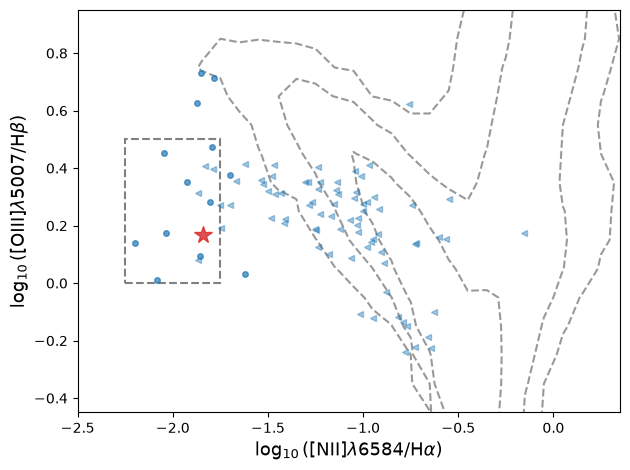

In [16]:
plt.figure(3, clear=True)

plt.contour(
    x_centers,
    y_centers,
    H,
    [10, 100, 1000],
    origin="lower",
    linestyles="--",
    colors="0.6",
)

rect = plt.Rectangle(
    (-2.25, 0.0),
    0.5,
    0.5,
    linewidth=1.5,
    edgecolor="gray",
    facecolor="none",
    linestyle="--",
)
plt.gca().add_patch(rect)

detections = emps["vg_nii6583"] / emps["vg_nii6583_err"] > 2

plt.plot(
    emps[detections]["vg_N2"],
    emps[detections]["vg_R3"],
    "o",
    color="tab:blue",
    markersize=4,
    alpha=0.7,
)

plt.plot(
    np.log10(2 * emps[~detections]["vg_nii6583_err"] / emps[~detections]["vg_ha"]),
    emps[~detections]["vg_R3"],
    "<",
    color="tab:blue",
    alpha=0.4,
    markersize=4,
)

plt.plot(
    N2_stack,
    R3_stack,
    marker="*",
    color="tab:red",
    markersize=13,
    alpha=0.8,
    label="stacked spectrum",
)

plt.xlim(-2.5, 0.35)
plt.ylim(-0.45, 0.95)
plt.xlabel(r"$\log_{10}([\mathrm{NII}]\lambda6584 / \mathrm{H}\alpha)$", fontsize=13)
plt.ylabel(r"$\log_{10}([\mathrm{OIII}]\lambda5007 / \mathrm{H}\beta)$", fontsize=13)
plt.tight_layout()

plt.show()

Text(0.5, 0, 'OIII 4363')

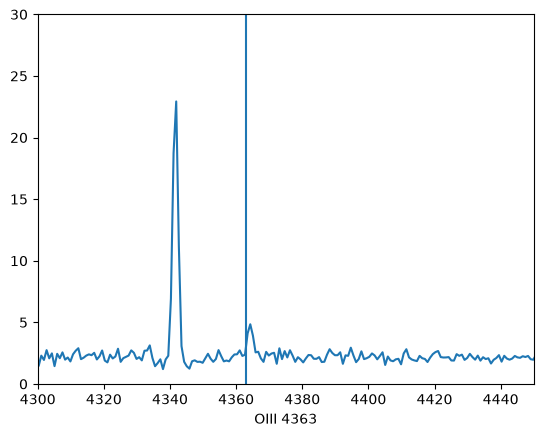

In [17]:
plt.plot(stack["wavelength"], stack["flux"], color="tab:blue")
plt.xlim(4300, 4450)
plt.ylim(0, 30)
plt.axvline(4363)
plt.xlabel("OIII 4363")

Text(0.5, 0, 'OII 7320, 7330')

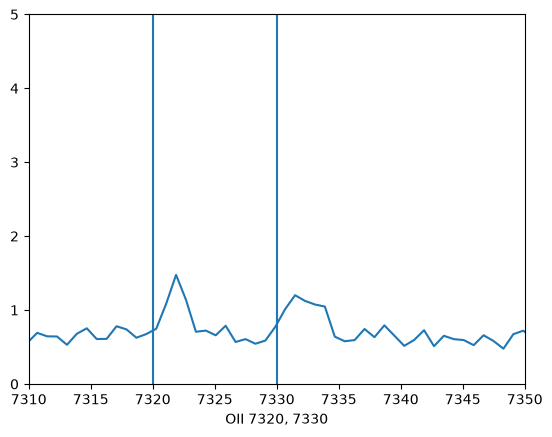

In [18]:
plt.plot(stack["wavelength"], stack["flux"], color="tab:blue")
plt.xlim(7310, 7350)
plt.ylim(0, 5)
plt.axvline(7320)
plt.axvline(7330)
plt.xlabel("OII 7320, 7330")

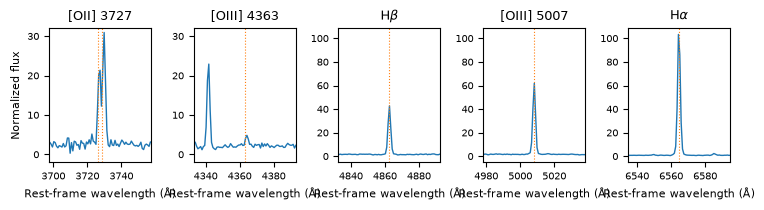

In [19]:
fig, axes = plt.subplots(1, 5, figsize=(7.5, 2.2), clear=True)

panels = [
    ("[OII] 3727", [3726.032, 3728.815], 30),
    ("[OIII] 4363", [4363], 30),
    (r"H$\beta$", [4862.683], 30),
    ("[OIII] 5007", [5008.24], 30),
    (r"H$\alpha$", [6564.61], 30),
]

for ax, (label, centers, half_width) in zip(axes, panels):
    ax.plot(stack["wavelength"], stack["flux"], color="tab:blue", lw=1)
    for center in centers:
        ax.axvline(center, color="tab:orange", ls=":", lw=0.8)
    center = np.mean(centers)
    ax.set_xlim(center - half_width, center + half_width)
    ax.set_title(label, fontsize=9)
    ax.set_xlabel("Rest-frame wavelength (Å)", fontsize=8)
    ax.tick_params(labelsize=7)

axes[0].set_ylabel("Normalized flux", fontsize=8)
axes[0].set_ylim(-2, 32)
axes[1].set_ylim(-2, 32)

fig.tight_layout()
plt.show()


## Fluxes from the stacked spectrum

Fit each requested line with the Gaussian model from `emline-inspect-functions.py`. The continuum is estimated independently in local windows for each line, and the fitted Gaussian amplitude is the integrated line flux.

In [20]:
stack_line_groups = {
    "oii3727": ([3726.032, 3728.815], [(3680, 3710), (3745, 3775)]),
    "oiii4363": ([4363.210], [(4300, 4340), (4380, 4420)]),
    "hb": ([4862.683], hb_window),
    "oiii5007": ([5008.240], o3_b_window),
    "ha": ([6564.610], [(6500, 6530), (6600, 6630)]),
}

stack_fluxes = []
for name, (centers, continuum_windows) in stack_line_groups.items():
    rest_wave = np.asarray(stack["wavelength"])
    flux = np.asarray(stack["flux"])
    ivar = np.asarray(stack["ivar"])
    mask = (
        np.isfinite(rest_wave)
        & np.isfinite(flux)
        & np.isfinite(ivar)
        & (ivar > 0)
        & (rest_wave >= continuum_windows[0][0])
        & (rest_wave <= continuum_windows[1][1])
    )
    fit_wave = rest_wave[mask]
    fit_flux = flux[mask]
    fit_ivar = ivar[mask]
    model = make_gaussian_model(centers)
    p0 = initial_guesses(0.0, centers, continuum_windows, (fit_wave, fit_flux))
    popt, pcov = curve_fit(
        model,
        fit_wave,
        fit_flux,
        p0=p0,
        sigma=1 / np.sqrt(fit_ivar),
        absolute_sigma=True,
        bounds=get_bounds(len(centers)),
    )
    perr = np.sqrt(np.diag(pcov))
    component_names = ["oii3726", "oii3729"] if name == "oii3727" else [name]
    for component_index, component_name in enumerate(component_names):
        stack_fluxes.append(
            {
                "line": component_name,
                "flux": popt[2 + component_index],
                "flux_err": perr[2 + component_index],
                "sigma": popt[1],
                "sigma_err": perr[1],
            }
        )

stack_fluxes = Table(rows=stack_fluxes).to_pandas().set_index("line")
stack_fluxes

,flux,flux_err,sigma,sigma_err
line,,,,
oii3726,40.450635,1.405363,0.789817,0.018778
oii3729,56.297786,1.490232,0.789817,0.018778
oiii4363,4.868184,0.690357,0.753105,0.120064
hb,80.511628,0.656266,0.783386,0.006896
oiii5007,118.323739,0.687099,0.787038,0.004826
ha,212.811189,0.606083,0.804122,0.002149


In [21]:
import pyneb as pn

In [22]:
o3 = pn.Atom("O", 3)
o2 = pn.Atom("O", 2)

ratio_4363_5007 = (
    stack_fluxes.loc["oiii4363", "flux"] / stack_fluxes.loc["oiii5007", "flux"]
)
ne_val = 300  # cm^-3

te_val = o3.getTemDen(int_ratio=ratio_4363_5007, den=ne_val, wave1=4363, wave2=5007)
te_low = 0.7 * te_val + 3000

print(f"Electron temperature (Te) from [OIII] 4363/5007 ratio: {te_val:.0f} K")

o3_abundance = o3.getIonAbundance(
    tem=te_val,
    den=ne_val,
    int_ratio=stack_fluxes.loc["oiii5007", "flux"]
    / stack_fluxes.loc["hb", "flux"]
    * 100,  # I was missing this factor of 100, which is needed for the calculation
    wave=5007,
)

print(f"OIII abundance : {o3_abundance:.2e}")

o2_abundance = o2.getIonAbundance(
    tem=te_low,
    den=ne_val,
    int_ratio=(
        stack_fluxes.loc["oii3726", "flux"] + stack_fluxes.loc["oii3729", "flux"]
    )
    / stack_fluxes.loc["hb", "flux"],
    wave=3727,
)

total_oh = o3_abundance + o2_abundance
print(f"Total oxygen abundance 12+log(O/H): {12 + np.log10(total_oh):.2f}")


Electron temperature (Te) from [OIII] 4363/5007 ratio: 22859 K
OIII abundance : 6.25e-06
Total oxygen abundance 12+log(O/H): 6.80
